<center><h1>Numerical approximation</h1></center>
<center><h3>Least squares linear fitting</h3></center>

- - - - - - - - - - - - - - -

In [1]:
import numpy as np
from IPython.display import Image

- - - - - - - - - - - - - - -

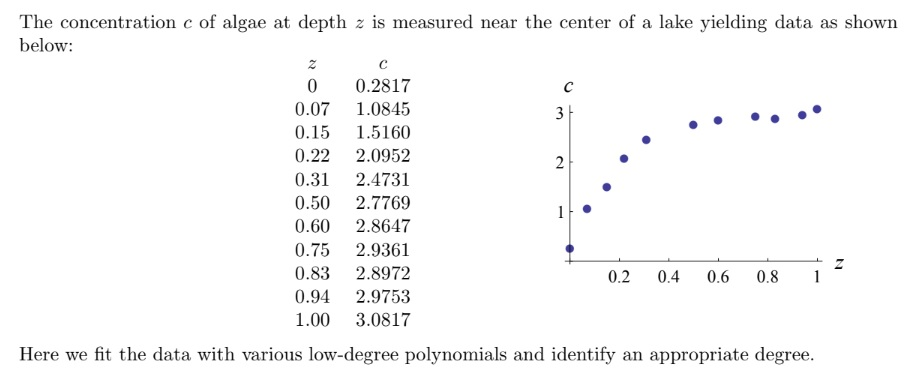

In [2]:
Image('algae.jpg')

Find the least-squares polynomial of degree $n = 1, 2, 3$ for the above data. For each $n$, report the polynomial $P_{n}(x)$ and the fitting error $E_{n} = \sum_{k}[y_{k} - P_{n}(x_{k})]^{2}$. Does $E_{n}$ decrease as $n$ increase? Briefly explain why this should happen. One simple way to identify an appropriate fitting degree
is to increase $n$ until the relative change $|E_{n} - E_{n-1}|/E_{n-1}$ is moderately small, say < $5\%$. Use this criterion to find an appropriate degree.

In [3]:
def ls_linear(dim):
    m = len(x)
    count = 0
    error = 0
    prev_error = 0
    poly = 0
    fdeg = 1
    
    while fdeg > 0.005:
        '''We initialise A as a matrix of zeros of (n+1)-dimension and B as an array of zeros of (n+1) dimensions.'''
        A = np.zeros((dim + 1, dim + 1))
        b = [0] * (dim + 1)
        
        pb = 0

        '''Defining the least-squares array and matrix using a power bias and the data provided.'''
        for i in range(dim + 1):
            for j in range(dim + 1):
                for k in range(m):
                    A[i][j] += (x[k]**(j + pb))
            pb += 1
        
        for i in range(dim + 1):
            for k in range(m):
                b[i] += (y[k] * (x[k])**i)

        '''Using the linear fitting function already provided by Numpy.'''
        alpha = np.polyfit(x, y, dim)
        alpha = alpha[::-1]

        '''Generating the fitting error to keep track when it falls below the accepted threshold.'''
        for i in range(dim + 1):
            poly += (alpha[i] * x**i)
        
        for k in range(m):
            error += (y[k] - poly[k])**2
        
        if (prev_error == 0):
            fdeg = error
        else:
            fdeg = abs(error - prev_error)/prev_error
        prev_error = error
    
        dim += 1
        count += 1
        error = 0
        poly = 0

    return count, A, b, alpha, prev_error, fdeg

if __name__ == "__main__":
    dim = 1
    x = np.array([0.0000, 0.0700, 0.1500, 0.2200, 0.3100, 0.5000, 0.6000, 0.7500, 0.8300, 0.9400, 1.0000])
    y = np.array([0.2817, 1.0845, 1.5160, 2.0952, 2.4731, 2.7769, 2.8647, 2.9361, 2.8972, 2.9753, 3.0817])
    count, A, b, alpha, error, fdeg = ls_linear(dim)

    print(f'Least-squares degree: {count}')
    print('Least-squares matrix: A =')
    print(A)
    print(f'Least-squares array: b = {b}')
    print(f'Least-squares solution: a**(k) = {alpha}')
    print(f'Least-squares fitting error: {error}')
    print(f'Fitting degree: {fdeg}')

Least-squares degree: 5
Least-squares matrix: A =
[[11.          5.37        3.9169      3.209403    2.77594645  2.47757867]
 [ 5.37        3.9169      3.209403    2.77594645  2.47757867  2.25808206]
 [ 3.9169      3.209403    2.77594645  2.47757867  2.25808206  2.08942988]
 [ 3.209403    2.77594645  2.47757867  2.25808206  2.08942988  1.95570452]
 [ 2.77594645  2.47757867  2.25808206  2.08942988  1.95570452  1.84707825]
 [ 2.47757867  2.25808206  2.08942988  1.95570452  1.84707825  1.75712069]]
Least-squares array: b = [24.982400000000002, 15.123423, 11.462126049999998, 9.515547054299999, 8.281987860732999, 7.421067991185028]
Least-squares solution: a**(k) = [  0.29949724  11.280953   -17.30326488  10.57148962  -2.1544067
   0.37807804]
Least-squares fitting error: 0.02819312904986171
Fitting degree: 0.00010974303343554247


More iteration would better perfect the approximation, hence why increases to $n$ decreases $E_{n}$. Also it would take up to the 5th degree before the error is < $5\%$.

## Further readings:
Reading material:<br>
https://www.amazon.com/Numerical-Analysis-Richard-L-Burden/dp/1305253663/

## Useful links:
Quick definition:<br>
https://mathworld.wolfram.com/LeastSquaresFitting.html